# Student Grade Prediction with Machine Learning

This notebook predicts a student's **grade class** (A–F) from study habits, attendance, parental involvement and extracurricular activities, and compares a **Random Forest** classifier with **Logistic Regression**.

**Dataset:** [Students Performance Dataset (Kaggle)](https://www.kaggle.com/datasets/rabieelkharoua/students-performance-dataset) — 2,392 students. Download the CSV and save it as `Student_performance_data.csv` in the same folder as this notebook.

**Target — `GradeClass`:** 0 = A (GPA ≥ 3.5), 1 = B, 2 = C, 3 = D, 4 = F (GPA < 2.0)

**Workflow:** Load & explore → Clean (missing values, IQR outliers) → Encode & scale → Train/test split + SMOTE → Tune models with GridSearchCV → Evaluate & compare → Visualise insights

## Setup: Import Libraries

In [ ]:
import pandas as pd  # For data manipulation
import matplotlib.pyplot as plt  # For visualizations
import joblib  # Library for saving the model
import numpy as np  # For numerical operations
import seaborn as sns  # For data visualization
from imblearn.over_sampling import SMOTE  # To handle class imbalance
from collections import Counter  # To count occurrences
from sklearn.preprocessing import LabelEncoder  # For encoding categorical variables
from sklearn.preprocessing import StandardScaler  # For scaling features
from sklearn.model_selection import train_test_split  # For splitting data into training and testing sets
from sklearn.ensemble import RandomForestClassifier  # Random Forest model
from sklearn.model_selection import GridSearchCV  # For hyperparameter tuning
from sklearn.linear_model import LogisticRegression  # Logistic Regression model
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             classification_report, confusion_matrix,
                               ConfusionMatrixDisplay)  # For model evaluation


## 1. Data Loading and Preprocessing

- **Missing values:** numeric columns filled with the mean, categorical columns with the mode
- **Outliers:** removed using the IQR (Interquartile Range) method
- **Encoding:** categorical columns converted to numeric values
- **Feature selection:** `StudentID` dropped (identifier only) and `GPA` dropped to **prevent data leakage**, since `GradeClass` is calculated directly from GPA
- **Scaling:** features standardised with `StandardScaler`
- **Split:** 70% training / 30% testing
- **Class imbalance:** **SMOTE** applied to the training set only, so every grade class is equally represented during training


=== First Few Rows of the Dataset ====
   StudentID   Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  \
0       1001  17.0       1        0.0                  2        19.833723   
1       1002  18.0       0        0.0                  1        15.408756   
2       1003  15.0       0        2.0                  3         4.210570   
3       1004  17.0  100000        0.0                  3        10.028829   
4       1005  17.0       1        NaN                  2         4.672495   

   Absences  Tutoring  ParentalSupport  Extracurricular  Sports  Music  \
0         7         1                2              0.0       0      1   
1         0         0                1              NaN       0      0   
2        26         0                2              0.0       0      0   
3        14         0                3              1.0       0      0   
4        17         1                3              0.0       0      0   

   Volunteering       GPA  GradeClass  
0           

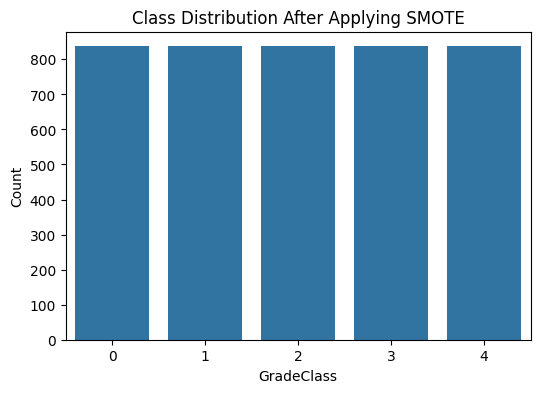

Class Distribution After SMOTE: Counter({4: 837, 3: 837, 0: 837, 2: 837, 1: 837})
Training set size: (1671, 12)
Testing set size: (717, 12)
-------------------------------------------------------


In [13]:
# ----------------------------------- Load and Explore Dataset -----------------------------------
# Loading the CSV file into a DataFrame
df = pd.read_csv('Student_performance_data.csv')
print("\n=== First Few Rows of the Dataset ====")
print(df.head())
print("-" * 55)

# Exploring the dataset
print("\n=== Basic Information about the Dataset ===")
print(df.info())
print("-" * 55)

#Displaying Summary Statistics
print("\n=== Summary Statistics for Numerical Columns ===")
print(df.describe())
print("-" * 55)

# Select numeric columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
numeric_cols = [col for col in numeric_cols if col != 'StudentID']


# ------------------------ 1. Data Preprocessing ------------------------
# ----------------------1.1 Check for missing values ----------------------
print("\n=== Missing Values Count Before Handling ===")
print(df.isnull().sum())
print("-" * 55)

#Displaying rows with missing values
print("\n===  Rows with Missing Values  ===")
print(df[df.isnull().any(axis=1)])
print("-" * 55)

# Handling the missing values
numeric_columns = df.select_dtypes(include=['number']).columns
for col in numeric_columns:
    if df[col].isnull().sum() > 0:
      df[col] = df[col].fillna(df[col].mean())

# Handling the missing values
categorical_columns = df.select_dtypes(include=['object']).columns
for col in categorical_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])


# Checking for the missing values after handling
print("\n===  Missing Values Count After Handling  ===")
print(df.isnull().sum())
print("-" * 55)

# ----------------------------------- Outlier Detection and Removal -----------------------------------
# Function to remove outliers using the IQR (Inter Quartile Range) method
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]


# Apply IQR outlier removal to specific numeric columns
numeric_columns = ['Age', 'StudyTimeWeekly', 'Tutoring', 'Gender']
for col in numeric_columns:
    if col in df.columns: #Check if the column exists in the DataFrame
        df = remove_outliers_iqr(df, col)
        print(f"After removing outliers in {col}, shape of DataFrame: {df.shape}")

print("\n===  Dataset After Removing Outliers Using IQR Method ===")
print(df.head())
print("-" * 55)

# -------------------------------- 1.2 Encoding Categorical Variables -----------------------------------
label_encoder = LabelEncoder()
for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

# Convert categorical columns to dummy variables
df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

print("\n===  Dataset After Encoding Categorical Variables  ===")
print(df.head())
print("-" * 55)

# --------------------------------- 1.3 Feature Scaling -----------------------------------

# Drop irrelevant columns (`StudentID` and `GPA`)
df = df.drop(columns=['StudentID','GPA'])
label_encoder = LabelEncoder()
df['GradeClass'] = label_encoder.fit_transform(df['GradeClass'])  # Encode target labels

# Define features (X) and target (y)
X = df.drop(columns=['GradeClass'])
y = df['GradeClass']  # The target variable

# Initializing & scaling feature columns
scaler = StandardScaler()
X = scaler.fit_transform(X)

# --------------------- 1.4 Split the data into training and testing sets -------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#Applying SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Visualize the class distribution after SMOTE (First Graph)
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_smote)
plt.title("Class Distribution After Applying SMOTE")
plt.xlabel("GradeClass")
plt.ylabel("Count")
plt.show()

# Display the distribution of classes
print("Class Distribution After SMOTE:", Counter(y_train_smote))

# Print the size of the training and testing sets
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("-" * 55)

# Ensure the target variable is categorical
y_train = y_train.astype('int')
y_test = y_test.astype('int')


## 2. Model Training with Hyperparameter Tuning

Both models are tuned with **GridSearchCV** (3-fold cross-validation):

- **Random Forest:** `n_estimators` ∈ {50, 100, 200}, `max_depth` ∈ {10, 20, 30}. An ensemble of decision trees that captures non-linear relationships.
- **Logistic Regression:** `C` ∈ {0.1, 1, 10, 100}, with L2 and Elastic Net penalties and the `saga` solver. A simpler, interpretable baseline.

In [3]:
# ------------------------------- 2. Model Selection and Training Models -----------------------------------
# ----------------------------------- 2.1 Train Random Forest Model -----------------------------------

# Defining the hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30],
}
# Define the model
model_rf = RandomForestClassifier(random_state=42)

# Perform Grid Search with 3-fold cross-validation
grid_search = GridSearchCV(estimator=model_rf, param_grid=param_grid, cv=3, scoring='accuracy', verbose=0, n_jobs=-1)
grid_search.fit(X_train_smote, y_train_smote)

# Best parameters and accuracy
print("\nBest Parameters for Random Forest:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

# Update the model with the best parameters
best_rf_model = grid_search.best_estimator_

# Save the best model
joblib.dump(best_rf_model, 'best_random_forest_model.pkl')

# Print confirmation
print("Random Forest model has been trained and saved successfully.")
print("-" * 55)

# ----------------------------------- 2.2 Train Logistic Regression Model -----------------------------------
# Defining the hyperparameter grid
param_grid_lr = [
    {'C': [0.1, 1, 10, 100], 'penalty': ['l2'], 'solver': ['saga']},  # Parameters for l2 penalty
    {'C': [0.1, 1, 10, 100], 'penalty': ['elasticnet'], 'solver': ['saga'], 'l1_ratio': [0.25, 0.5, 0.75]},  # Parameters for elasticnet penalty
]

# Initialize Logistic Regression model
model_lr = LogisticRegression(random_state=42, max_iter=5000)

# Perform Grid Search with 3-fold cross-validation
grid_search_lr = GridSearchCV(estimator=model_lr, param_grid=param_grid_lr, cv=3, scoring='accuracy', verbose=0, n_jobs=-1, error_score='raise') # Raise errors for invalid combinations
grid_search_lr.fit(X_train_smote, y_train_smote)

# Best parameters and accuracy
print("\n \nBest Parameters for Logistic Regression:", grid_search_lr.best_params_)
print("Best Cross-Validation Accuracy for Logistic Regression:", grid_search_lr.best_score_)

# Update the model with the best parameters
best_lr_model = grid_search_lr.best_estimator_

# Save the best Logistic Regression model
joblib.dump(best_lr_model, 'best_logistic_regression_model.pkl')

# Print confirmation
print("Logistic Regression model has been trained and saved successfully.")
print("-" * 55)



Best Parameters for Random Forest: {'max_depth': 20, 'n_estimators': 200}
Best Cross-Validation Accuracy: 0.8941457586618876
Random Forest model has been trained and saved successfully.
-------------------------------------------------------

 
Best Parameters for Logistic Regression: {'C': 0.1, 'l1_ratio': 0.75, 'penalty': 'elasticnet', 'solver': 'saga'}
Best Cross-Validation Accuracy for Logistic Regression: 0.5670250896057348
Logistic Regression model has been trained and saved successfully.
-------------------------------------------------------


## 3. Prediction and Evaluation

Each model is evaluated on the unseen test set using accuracy, precision, recall and F1-score (weighted across classes), plus a per-class classification report and confusion matrix.



=== Random Forest Model Evaluation ===
Accuracy: 0.71
Precision: 0.70
Recall: 0.71
F1-Score: 0.71

=== Classification Report for Random forest Model: ===
               precision    recall  f1-score   support

           0       0.28      0.29      0.28        28
           1       0.55      0.55      0.55        78
           2       0.54      0.51      0.53       117
           3       0.51      0.46      0.48       122
           4       0.88      0.92      0.90       372

    accuracy                           0.71       717
   macro avg       0.55      0.55      0.55       717
weighted avg       0.70      0.71      0.71       717

-------------------------------------------------------


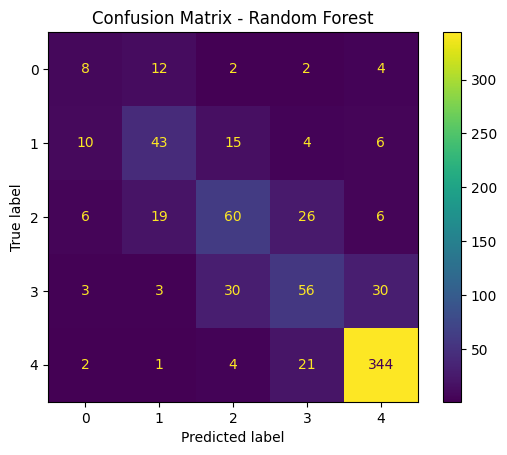

Logistic Regression Model Evaluation:
Accuracy: 0.65
Precision: 0.69
Recall: 0.65
F1-Score: 0.66

=== Classification Report for Logistic Regression Model ===
               precision    recall  f1-score   support

           0       0.16      0.43      0.23        28
           1       0.45      0.37      0.41        78
           2       0.49      0.41      0.45       117
           3       0.45      0.51      0.48       122
           4       0.91      0.84      0.88       372

    accuracy                           0.65       717
   macro avg       0.49      0.51      0.49       717
weighted avg       0.69      0.65      0.66       717

-------------------------------------------------------


In [4]:
# ------------------------ 3. Prediction and Evaluation ------------------------
# ------------------------ 3.1 Random Forest Evaluation ------------------------

# Predictions on the test dataset using the trained Random Forest model
y_prediction_rf = best_rf_model.predict(X_test)

# Calculate evaluation metrics
accuracy_rf = accuracy_score(y_test, y_prediction_rf)
precision_rf = precision_score(y_test, y_prediction_rf, average='weighted')
recall_rf = recall_score(y_test, y_prediction_rf, average='weighted')
f1_rf = f1_score(y_test, y_prediction_rf, average='weighted')

# Print the evaluation metrics
print("\n\n=== Random Forest Model Evaluation ===")
print(f"Accuracy: {accuracy_rf:.2f}")
print(f"Precision: {precision_rf:.2f}")
print(f"Recall: {recall_rf:.2f}")
print(f"F1-Score: {f1_rf:.2f}")

# Print classification report for Random forest Model
print("\n=== Classification Report for Random forest Model: ===\n", classification_report(y_test, y_prediction_rf))
print("-" * 55)

# ---------------------------- 4. Visualization and Insights ------------------------
# ------------------- 4.1 Confusion Matrix for Random Forest (Graph 2) ---------------------

ordered_labels = sorted(y.unique())
conf_matrix_rf = confusion_matrix(y_test, y_prediction_rf)

# Display Confusion Matrix
disp_rf = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_rf, display_labels=ordered_labels)
disp_rf.plot(cmap='viridis')
plt.title("Confusion Matrix - Random Forest")
plt.show()

# ------------------------ 3.2 Logistic Regression Evaluation ------------------------

# Predictions on the test dataset using Logistic Regression Model
y_pred_lr = best_lr_model.predict(X_test)

#Calculate evaluation metrics for Logistic Regression
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, average='weighted')
recall_lr = recall_score(y_test, y_pred_lr, average='weighted')
f1_lr = f1_score(y_test, y_pred_lr, average='weighted')

# Print the evaluation metrics
print("Logistic Regression Model Evaluation:")
print(f"Accuracy: {accuracy_lr:.2f}")
print(f"Precision: {precision_lr:.2f}")
print(f"Recall: {recall_lr:.2f}")
print(f"F1-Score: {f1_lr:.2f}")

# Print classification report for Logistic Regression model
print("\n=== Classification Report for Logistic Regression Model ===\n", classification_report(y_test, y_pred_lr))
print("-" * 55)

## 4. Model Comparison

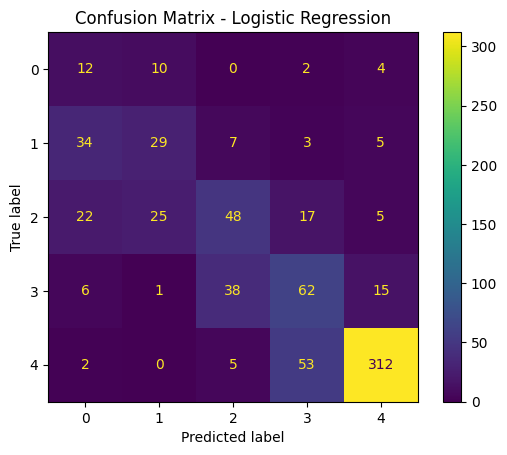


=== Random Forest VS Logistic Regression ===

Metric          Random Forest        Logistic Regression 
-------------------------------------------------------
Accuracy        0.7127               0.6457              
Precision       0.7040               0.6863              
Recall          0.7127               0.6457              
F1-Score        0.7078               0.6615              

=== Conclusion ===
Based on the F1-Score, the Random Forest model performs better.


In [9]:
# ---------------------------- 4. Visualization and Insights ------------------------
# ---------------- 4.2 Confusion Matrix for Logistic Regression (Graph 3) --------------------

conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)
# Displaying the Confusion Matrix
disp_lr = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_lr, display_labels=ordered_labels)
disp_lr.plot(cmap='viridis')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# --------------- 3.3 Comparison Table (Random forest Vs Logistic Regression) ------------------
comparison = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Random Forest": [accuracy_rf, precision_rf, recall_rf, f1_rf],
    "Logistic Regression": [accuracy_lr, precision_lr, recall_lr, f1_lr]
}

# Print metrics in a table format
print("\n=== Random Forest VS Logistic Regression ===\n")
print("{:<15} {:<20} {:<20}".format("Metric", "Random Forest", "Logistic Regression"))
print("-" * 55)

for i in range(len(comparison["Metric"])):
    print("{:<15} {:<20.4f} {:<20.4f}".format(
        comparison['Metric'][i],
        comparison['Random Forest'][i],
        comparison['Logistic Regression'][i]
    ))

# Determine which model is better
better_model = {
    "Accuracy": "Random Forest" if accuracy_rf > accuracy_lr else "Logistic Regression",
    "Precision": "Random Forest" if precision_rf > precision_lr else "Logistic Regression",
    "Recall": "Random Forest" if recall_rf > recall_lr else "Logistic Regression",
    "F1-Score": "Random Forest" if f1_rf > f1_lr else "Logistic Regression"
}

# Conclusion based on overall performance
primary_metric = "F1-Score"
if f1_rf > f1_lr:
    conclusion = f"Based on the {primary_metric}, the Random Forest model performs better."
elif f1_rf < f1_lr:
    conclusion = f"Based on the {primary_metric}, the Logistic Regression model performs better."
else:
    conclusion = f"Both models have comparable performance based on the {primary_metric}."

print("\n=== Conclusion ===")
print(conclusion)


## 5. Feature Importance

Which factors matter most? Random Forest importance scores are compared with the absolute coefficients from Logistic Regression (shown for the class 0 / grade A model).

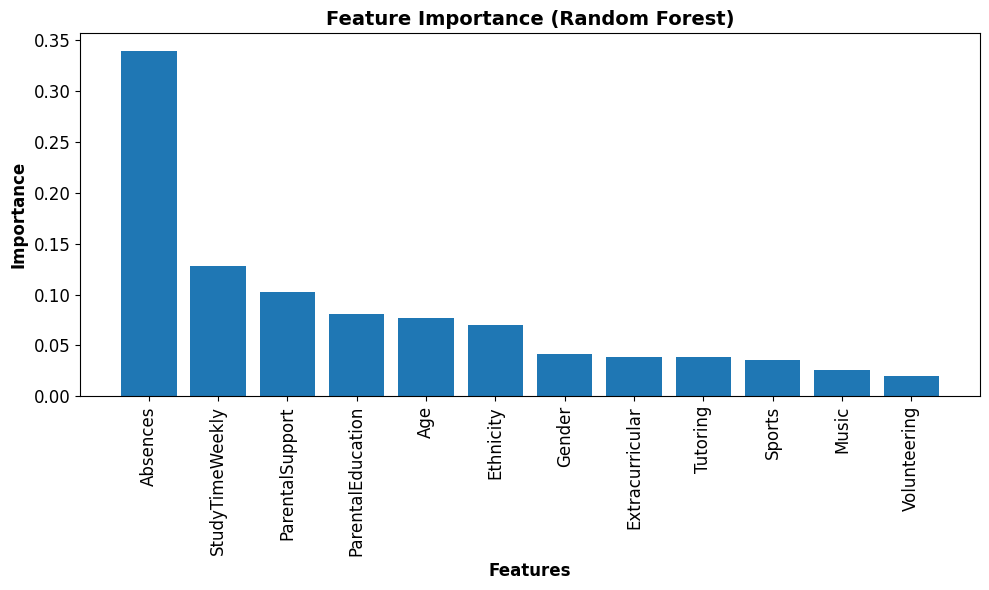

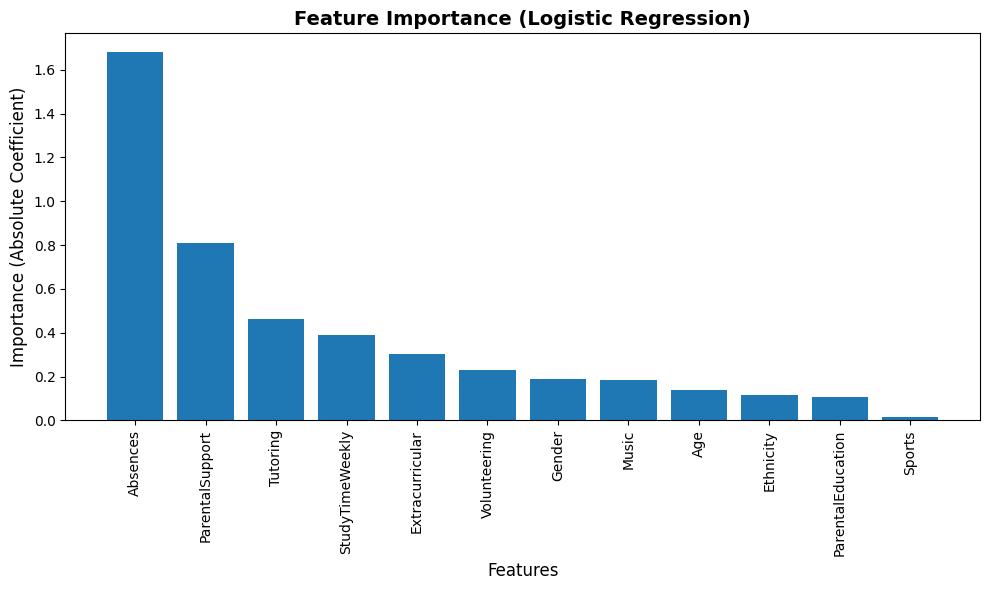

In [6]:
# --------------------- 4.3 Feature Importance for Random Forest ------------------------
# ---------------------------          (Graph 4)            ------------------------

# Get the feature names from the processed DataFrame
feature_names = df.drop(columns=['GradeClass']).columns

# Defining a function to plot feature importance
def plot_feature_importance(model, feature_names):
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]  # Sort descending

    plt.figure(figsize=(10, 6))
    plt.title("Feature Importance (Random Forest)", fontsize=14, fontweight='bold')
    plt.bar(range(len(importances)), importances[indices], align="center")
    plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
    plt.xlabel("Features", fontsize=12, fontweight='bold')
    plt.ylabel("Importance", fontsize=12, fontweight='bold')
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    plt.show()

# Call the function with your trained model and feature names
plot_feature_importance(best_rf_model, feature_names)

# --------------------- 4.3 Feature Importance for Logistic Regression ------------------------
# ---------------------------          (Graph 5)            ------------------------
# Extract feature names
feature_names = df.drop(columns=['GradeClass']).columns

# Train Logistic Regression model
logistic_model = LogisticRegression(random_state=42, max_iter=1000)
logistic_model.fit(X_train_smote, y_train_smote)

# Plot feature importance based on Logistic Regression coefficients
def plot_logistic_feature_importance(model, feature_names):
    coefficients = model.coef_[0]  # Coefficients for the first class
    importance = np.abs(coefficients)
    indices = np.argsort(importance)[::-1]  # Sort descending

    plt.figure(figsize=(10, 6))
    plt.title("Feature Importance (Logistic Regression)", fontsize=14, fontweight='bold')
    plt.bar(range(len(importance)), importance[indices], align="center")
    plt.xticks(range(len(importance)), feature_names[indices], rotation=90)
    plt.xlabel("Features", fontsize=12)
    plt.ylabel("Importance (Absolute Coefficient)", fontsize=12)
    plt.tight_layout()
    plt.show()

# Call the function with your trained logistic regression model and feature names
plot_logistic_feature_importance(logistic_model, feature_names)



## 6. Residual Comparison

Residuals (actual class − predicted class) show how far off each model's mistakes are. Values clustered tightly around 0 mean fewer and smaller errors.

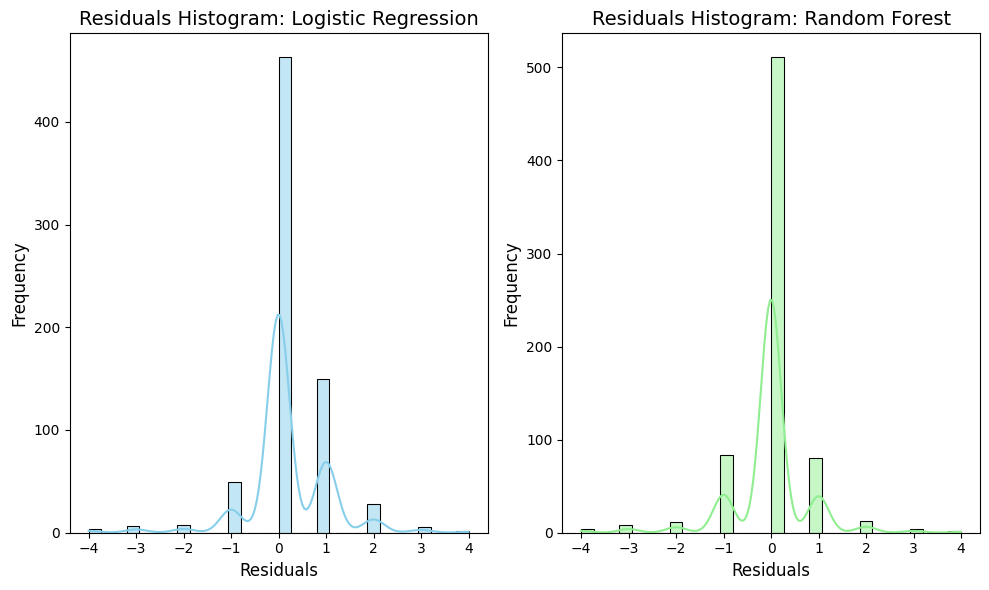

In [12]:
# ------------------------ Additional Visualization  ------------------------
# ---------------------------   (Graph 6)     ------------------------

def plot_residuals_comparison(y_test, y_pred_rf, y_pred_lr):
    # Calculate residuals
    residuals_rf = y_test - y_pred_rf
    residuals_lr = y_test - y_pred_lr

    # Create a figure with two subplots side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))

    # Plot for Logistic Regression
    sns.histplot(residuals_lr, bins=30, kde=True, color='skyblue', ax=ax1)
    ax1.set_title("Residuals Histogram: Logistic Regression", fontsize=14)
    ax1.set_xlabel("Residuals", fontsize=12)
    ax1.set_ylabel("Frequency", fontsize=12)

    # Plot for Random Forest
    sns.histplot(residuals_rf, bins=30, kde=True, color='lightgreen', ax=ax2)
    ax2.set_title("Residuals Histogram: Random Forest", fontsize=14)
    ax2.set_xlabel("Residuals", fontsize=12)
    ax2.set_ylabel("Frequency", fontsize=12)

    # Adjust layout and display
    plt.tight_layout()
    plt.show()

# Calculate predictions
y_pred_rf = best_rf_model.predict(X_test)
y_pred_logistic = best_lr_model.predict(X_test)

# Call the function to plot residuals
plot_residuals_comparison(y_test, y_pred_rf, y_pred_logistic)

## Conclusion

- **Random Forest performed best**, with **71.3% accuracy** and a **0.708 weighted F1-score**, compared with 64.6% and 0.662 for Logistic Regression.
- Both models are strongest at identifying **grade F students (class 4)**. Random Forest reached 0.88 precision and 0.92 recall for this class, which makes it useful for flagging **at-risk students** early.
- **Absences** are by far the strongest predictor of grade, followed by weekly study time and parental support.
- The middle grades (B–D) are harder to separate, as their feature profiles overlap.